In [159]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date
import math 

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

# import eurostat #python wrapper for taking data. 
import time

In [160]:
Share_point = r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage' # Ugne
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage' # Giovanni
# Share_point = r'C:\Users\ben.mcwilliams\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage' # Ben

In [161]:
import os
os.chdir(Share_point)

In [162]:
EU27 = pd.read_excel('eu27.xlsx')
Europe = pd.read_excel('MS + EU.xlsx', sheet_name='Europe') 

In [163]:
twodigit = Europe['API']  # FOR THE EU IT MUST BE TYPE=EU NOT COUNTRY=EU
# twodigit = EU27['twodigit']

In [164]:
import os
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [165]:
# headers = {"x-key":"c004438249338e49ed35e0ffce94cb6a"}
# print(headers)

In [166]:
from datetime import date
today = date.today()
print(today)

2025-03-27


## May need updating (every 6 months)

In [167]:
# headers = {"x-key":"c004438249338e49ed35e0ffce94cb6a"}
headers = {"x-key":"17d04ee4a722c5013cd92c83f08122a2"} # After July 4th

In [168]:
dates = []
values = []
percentages = []
status = []
max_storage = []
country = []

for idt in twodigit:
    try:
        url = 'https://agsi.gie.eu/api?{}&from=2025-01-01&to={}&size=300'.format(idt,str(today)) # to be changed at the beginning of new year and the first of July
        # url = 'https://agsi.gie.eu/api?{}&from=2024-01-01&to=2024-06-30&size=300'.format(idt)  
        r = requests.get(url,headers=headers)
        data = r.json()
        inner_data = data['data']
        for x in inner_data:
                #here we work with the APIs
#                 date = x['gasDayStartedOn']     # Changed on 5 April 2022
                date = x['gasDayStart']
                value = x['gasInStorage']
                percentage = x['full']
                statuses = x['status']
                Max_Storage = x['workingGasVolume']
                countries = x['code']


                dates.append(date)     
                values.append(value)
                percentages.append(percentage)
                status.append(statuses)
                max_storage.append(Max_Storage)
                country.append(countries)
    except Exception as e:
        print(e)
        print(idt)

'gasInStorage'
country=CY
'gasInStorage'
country=EE
'gasInStorage'
country=FI
'gasInStorage'
country=GR
'gasInStorage'
country=LT
'gasInStorage'
country=LU
'gasInStorage'
country=MT
'gasInStorage'
country=SI


In [169]:
df = pd.DataFrame()
df['dates'] = dates
df['values'] = values
df['% full'] = percentages
df['status'] = status
df['Max Storage'] = max_storage
df['country'] = country

In [170]:
# df = df.set_index(pd.DatetimeIndex(df['dates']))

In [171]:
# Getting rid of NaN
df.replace('', np.NaN)
# Getting rid of observations for which we have no data
df = df[df['status']!='N']

In [172]:
df['values'] = pd.to_numeric(df['values']) 
df['% full'] = pd.to_numeric(df['% full'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 

save data

In [173]:
# Change current directory
import os
os.chdir(Share_point + '\Storage by country\historic data (10.05.2022)')

In [174]:
df

,dates,values,% full,status,Max Storage,country
0,2025-03-25,44.0955,43.41,C,101.5869,AT
1,2025-03-24,44.3599,43.67,C,101.5869,AT
2,2025-03-23,44.5993,43.90,C,101.5869,AT
3,2025-03-22,44.5312,43.84,C,101.5869,AT
4,2025-03-21,44.4412,43.75,C,101.5869,AT
...,...,...,...,...,...,...
1927,2025-01-05,800.1481,69.72,E,1147.6446,eu
1928,2025-01-04,805.4127,70.18,E,1147.6446,eu
1929,2025-01-03,811.9160,70.75,E,1147.6446,eu
1930,2025-01-02,818.5682,71.33,E,1147.6446,eu


In [175]:
df.to_csv(r'Storage_2025_1.csv')
#df.to_csv(r'Storage_2024_1.csv')

### Merge historic and 2022 data

In [176]:
df_1a = pd.read_csv('Storage_2015_1.csv',index_col=0)
df_1b = pd.read_csv('Storage_2015_2.csv',index_col=0)
df_2a = pd.read_csv('Storage_2016_1.csv',index_col=0)
df_2b = pd.read_csv('Storage_2016_2.csv',index_col=0)
df_3a = pd.read_csv('Storage_2017_1.csv',index_col=0)
df_3b = pd.read_csv('Storage_2017_2.csv',index_col=0)
df_4a = pd.read_csv('Storage_2018_1.csv',index_col=0)
df_4b = pd.read_csv('Storage_2018_2.csv',index_col=0)
df_5a = pd.read_csv('Storage_2019_1.csv',index_col=0)
df_5b = pd.read_csv('Storage_2019_2.csv',index_col=0)
df_6a = pd.read_csv('Storage_2020_1.csv',index_col=0)
df_6b = pd.read_csv('Storage_2020_2.csv',index_col=0)
df_7a = pd.read_csv('Storage_2021_1.csv',index_col=0)
df_7b = pd.read_csv('Storage_2021_2.csv',index_col=0)
df_8a = pd.read_csv('Storage_2022_1.csv',index_col=0)
df_8b = pd.read_csv('Storage_2022_2.csv',index_col=0)
df_9a = pd.read_csv('Storage_2023_1.csv',index_col=0)
df_9b = pd.read_csv('Storage_2023_2.csv',index_col=0)
df_10a = pd.read_csv('Storage_2024_1.csv',index_col=0)
df_10b = pd.read_csv('Storage_2024_2.csv',index_col=0)
df_11a = pd.read_csv('Storage_2025_1.csv',index_col=0) #changed 

In [177]:
df = pd.concat([df_1a,df_1b,df_2a,df_2b,df_3a,df_3b,df_4a,df_4b,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a,df_10b,df_11a])

In [178]:
# df = df.sort_values('dates')
# df = df.sort_values('country')

In [179]:
from datetime import date
# storage data by country in TWh
df.to_csv(Share_point + '\Storage by country\Storage by country {}.csv'.format(date.today()))

In [180]:
## Get rid of the following when the APIs work again

In [181]:
dff = df.groupby(['country','dates'])['values'].mean().reset_index()

#### Eu overall storage

In [182]:
EUdff = df.groupby(['country','dates'])['values'].sum().reset_index()
EUdff = EUdff.set_index(pd.DatetimeIndex(EUdff['dates']))
# EUdff[EUdff['dates']>'2023-06-25'].iloc[:20]

In [183]:
del EUdff['dates']

In [184]:
# Weekly data for the EU in M3m
converter=0.0103
euplot_days = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()/converter
# euplot_days.to_csv(Share_point + '\EU weekly\EU storage data {}.csv'.format(date.today()))

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\3684749521.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  euplot_days = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()/converter


In [185]:
euplot_days

,values
dates,
2015-01-04,71993.560680
2015-01-11,69195.400832
2015-01-18,65849.622746
2015-01-25,61423.070735
2015-02-01,56587.077670
...,...
2025-03-02,43537.621359
2025-03-09,41180.862691
2025-03-16,39633.127601


In [186]:
EUdff.index.year.unique()

Int64Index([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype='int64', name='dates')

In [187]:
EU= EUdff[EUdff['country']== 'eu']

In [188]:
EU.tail()

,country,values
dates,,
2025-03-21,eu,387.9519
2025-03-22,eu,388.6363
2025-03-23,eu,388.9105
2025-03-24,eu,387.7408
2025-03-25,eu,386.6008


In [189]:
min_per_y = EU.groupby(EU.index.year)['values'].min()

In [190]:
for i in min_per_y:
    print(EU[EU['values']==i].index)

DatetimeIndex(['2015-04-09'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2016-03-30'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2017-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2018-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2019-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2020-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2021-04-20'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2022-03-19'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2023-04-06'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2024-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2025-03-25'], dtype='datetime64[ns]', name='dates', freq=None)


### Storage by country for Flourish

In [191]:
from datetime import date
today=date.today()

In [192]:
today

datetime.date(2025, 3, 27)

In [193]:
last_obs = today - timedelta(days=2)
print(last_obs)

2025-03-25


In [194]:
last_month = last_obs - timedelta(days=30)
print(last_month)

2025-02-23


In [195]:
df_Florish = df[['dates','values','% full','Max Storage','country']]

In [196]:
df_Florish = df_Florish.set_index(pd.DatetimeIndex(df['dates']))

In [197]:
del df_Florish['dates']

In [198]:
df_Florish = df_Florish[df_Florish.index.isin([str(last_obs),str(last_month)])]

In [199]:
countries = df_Florish['country'].unique()

In [200]:
countries.shape

(20,)

In [201]:
Date =[]
This_month_filling = []
State = []
Max_storage = []
values = []
Percent = []
Eighty_percent = []
Last_month = []
Forty_p = []
Twenty_p = []

for country in countries:
    df_Florish_new = df_Florish[df_Florish['country']== country] 
    latest_value = df_Florish_new.loc[str(last_obs),'values']#[0]
    perc = df_Florish_new.loc[str(last_obs),'% full']#[0]
    Prev_value = df_Florish_new.loc[str(last_month),'values']#[0]
    TWh = latest_value - Prev_value
        
    Capacity = df_Florish_new.iloc[0,2]
    Target = Capacity * 0.9 # before was 80% now 90%
    Twenty = Capacity * 0.2 # the minimum safety treshold
    Forty = Capacity * 0.4 # can forget about this one or change it to whatherver you want
    
    Date.append(last_obs)
    Percent.append(perc)
    Last_month.append(Prev_value)
    This_month_filling.append(TWh)
    values.append(latest_value) 
    State.append(country)
    Max_storage.append(Capacity)
    Eighty_percent.append(Target)
    Forty_p.append(Forty)
    Twenty_p.append(Twenty)

In [202]:
df_stack_bar = pd.DataFrame()
df_stack_bar['date']= Date
df_stack_bar['country'] = State
df_stack_bar['% full'] = Percent
df_stack_bar['latest values'] = values
df_stack_bar['30 days ago value'] = Last_month
df_stack_bar['Last 30 days change'] = This_month_filling
df_stack_bar['Max capacity'] = Max_storage
# df_stack_bar['80 % target'] = Eighty_percent
# df_stack_bar['40 %'] = Forty_p
# df_stack_bar['20 %'] = Twenty_p

In [203]:
### can skip all the following now (used for the withdrawing season only)

In [204]:
# just for graphical purposes
df_stack_bar['values root'] = df_stack_bar['latest values']**(1/2)

In [205]:
# capital letter for country names
df_stack_bar['country'] = df_stack_bar['country'].str.upper()

In [206]:
df_stack_bar.set_index('country',inplace=True)

In [207]:
# # months before getting to 20 or 40 percent
# days_20 =  ((df_stack_bar['latest values']-df_stack_bar['20 %'])/-df_stack_bar['Last 30 days change'])*30
# days_40 = ((df_stack_bar['latest values']-df_stack_bar['40 %'])/-df_stack_bar['Last 30 days change'])*30

In [208]:
# df_stack_bar['date to 20%'] = last_obs 
# df_stack_bar['date to 40%'] = last_obs 

In [209]:
df_stack_bar.drop('SE',inplace=True)

In [210]:
# df_stack_bar.loc['BG','date to 20%']

In [211]:
str(today)

'2025-03-27'

In [212]:
# print(df_stack_bar['Last 30 days change']['PT']>0)
# print(df_stack_bar['Last 30 days change']['AT'])

In [213]:
df_stack_bar.iloc[:,1:-2] =  round(df_stack_bar.iloc[:,1:-2],1) # just rounding, remember that Georg likes rounded numbers

In [214]:
df_stack_bar.head()

,date,% full,latest values,30 days ago value,Last 30 days change,Max capacity,values root
country,,,,,,,
AT,2025-03-25,43.4,44.1,52.3,-8.2,101.5869,6.640444
BE,2025-03-25,36.0,3.2,2.8,0.3,8.8300,1.782274
BG,2025-03-25,34.0,2.0,2.4,-0.4,5.9114,1.418238
HR,2025-03-25,10.2,0.5,1.0,-0.5,4.7725,0.699500
CZ,2025-03-25,34.0,15.3,18.3,-3.0,44.9674,3.908887


In [215]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage\\Storage by country\\historic data (10.05.2022)'

In [216]:
import os
os.chdir(Share_point)

In [217]:
df_stack_bar.to_excel(r'last 30 days\30 days storage levels {}.xlsx'.format(today))

## EU and single country last period analysis

In [218]:
# from datetime import date
# df = pd.read_csv('Storage by country/2021-12-15.csv')
# del df['Unnamed: 0']

In [219]:
type(df)

pandas.core.frame.DataFrame

In [220]:
df['country'].unique()

array(['AT', 'BE', 'BG', 'HR', 'CZ', 'DK', 'FR', 'DE', 'HU', 'IT', 'LV',
       'NL', 'PL', 'PT', 'RO', 'SK', 'ES', 'GB', 'eu', 'IE', 'SE', 'UA'],
      dtype=object)

### Choose country

In [221]:
dff = df.groupby(['country','dates'])['values'].mean().reset_index()

In [222]:
EUdff = df.groupby(['country','dates'])['values'].sum().reset_index()
EUdff = EUdff.set_index(pd.DatetimeIndex(EUdff['dates']))
EUdff.tail(3)

,country,dates,values
dates,,,
2025-03-23,eu,2025-03-23,388.9105
2025-03-24,eu,2025-03-24,387.7408
2025-03-25,eu,2025-03-25,386.6008


In [223]:
del EUdff['dates']

Data on AGSI+ are provided in Twh therefore to convert in M3m we have to divide by 0.0111868

# save in excel fo infogram

In [224]:
# os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage')
os.chdir(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage') #Ugne

In [225]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [226]:
converter

0.0103

In [227]:
df[df['country']=='UA']['Max Storage'].iloc[-1]/converter

30996.54368932039

In [228]:
data = pd.DataFrame()
# coverter_TWh_M3m = 97.08737864077669
# all coverted in M3m

for country in ['eu','UA']:
    df_comparison = EUdff[EUdff['country']==country]
    df_comparison = df_comparison.groupby(pd.Grouper(freq='W')).mean()
# df_comparison['weekly'] = df_comparison.index.week
    df_comparison['weekly'] = df_comparison.index.isocalendar().week
# df_comparison = df_comparison.set_index(pd.DatetimeIndex())
    minvalues = df_comparison['2015-01-05':'2021-01-02'].groupby('weekly').min(numeric_only=True)/converter
    maxvalues = df_comparison['2015-01-05':'2021-01-02'].groupby('weekly').max(numeric_only=True)/converter
    avgvalues = df_comparison['2015-01-05':'2021-01-02'].groupby('weekly').mean(numeric_only=True)/converter
    values2021 = df_comparison.loc['2021-01-02':'2022-01-02'].groupby('weekly').mean(numeric_only=True)/converter
    values2022 = df_comparison.loc['2022-01-03':'2023-01-01'].groupby('weekly').mean(numeric_only=True)/converter
    values2023 = df_comparison.loc['2023-01-02':'2023-12-31'].groupby('weekly').mean(numeric_only=True)/converter
    values2024 = df_comparison.loc['2024-01-01':'2024-12-29'].groupby('weekly').mean(numeric_only=True)/converter
    values2025 = df_comparison.loc['2024-12-30':].groupby('weekly').mean(numeric_only=True)/converter
    # change2022 = values2022['values'].diff()# *coverter_TWh_M3m if you do not use the other converter before
    # change2023 = values2023['values'].diff()# *coverter_TWh_M3m
    
    data['{}_min'.format(country)] = minvalues.round(1)
    data['{}_max'.format(country)] = maxvalues.round(1)
    data['{}_2021'.format(country)] = values2021.round(1)
    data['{}_2022'.format(country)] = values2022.round(1)
    data['{}_2023'.format(country)] = values2023.round(1)
    data['{}_2024'.format(country)] = values2024.round(1)
    data['{}_2025'.format(country)] = values2025.round(1)
    # data['{}_2022 change'.format(country)] = change2022.round(1)
    # data['{}_2023 change'.format(country)] = change2023.round(1)

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\1436689530.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_comparison = df_comparison.groupby(pd.Grouper(freq='W')).mean()
C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\1436689530.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_comparison = df_comparison.groupby(pd.Grouper(freq='W')).mean()


In [229]:
data['eu_2023'].iloc[23:]

weekly
24     80289.1
25     82343.9
26     84324.6
27     86455.2
28     88594.6
29     90783.8
30     92963.3
31     95165.8
32     97410.6
33     99792.1
34    101512.1
35    102553.3
36    103397.1
37    103825.6
38    104521.1
39    105520.0
40    106612.7
41    107757.8
42    108595.7
43    109275.2
44    110039.5
45    110169.6
46    109777.3
47    108634.1
48    105562.7
49    101578.9
50     98970.2
51     96829.6
52     95944.8
53         NaN
Name: eu_2023, dtype: float64

In [230]:
import os
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [231]:
from datetime import date
data.to_excel('EU weekly\Weekly Storage EU & UA {}.xlsx'.format(date.today()))

# not needed from here

In [232]:
#---------------------------------------------------------------------------------- not needed from here ---------------------------------------------------------------------------------------------------------------------------------------

# Monthly and weekly data

In [233]:
euplot_monthly = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='M')).mean(numeric_only=True)
euplot_weekly = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean(numeric_only=True)
# If we want to convert to Million Cubic meters
converter=0.0103
euplot2 = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='M')).mean(numeric_only=True)/converter
euplot2_weekly = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean(numeric_only=True)/converter

 This is in TWh

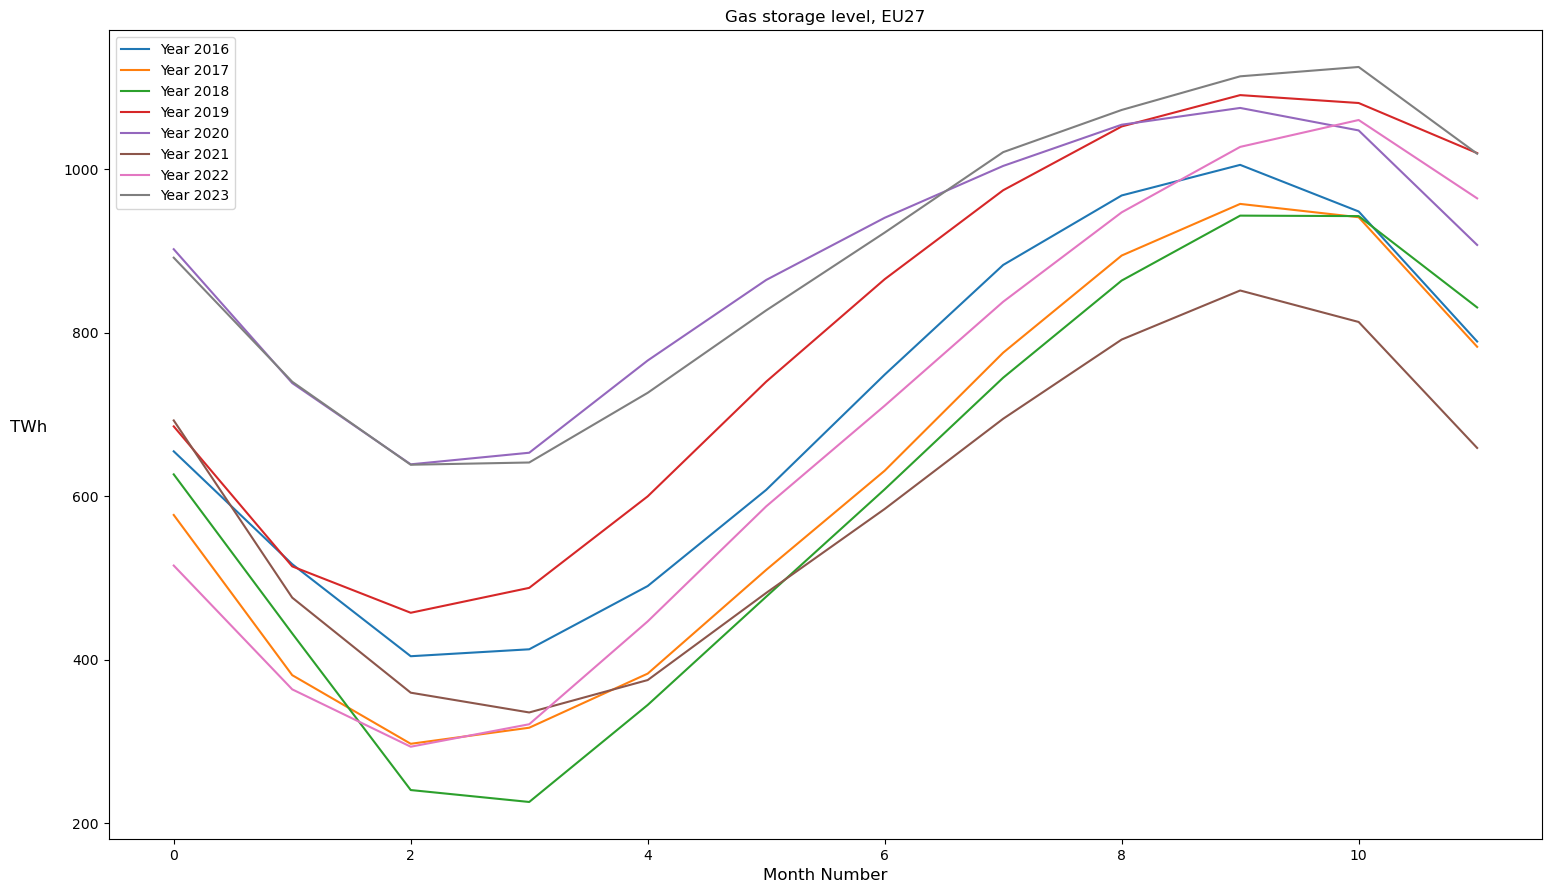

In [234]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
for yr in ['2016','2017','2018','2019','2020','2021','2022','2023']:
    ax.plot(euplot_monthly.loc[yr].values, label = 'Year {}'.format(yr))
    plt.legend(loc='best')
    plt.title('Gas storage level, EU27')
    plt.ylabel('TWh',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Month Number',fontsize=12,rotation=0)

In [235]:
EU = df['country'].unique()

In [236]:
#compare by week or month
compare = 'weekly'

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


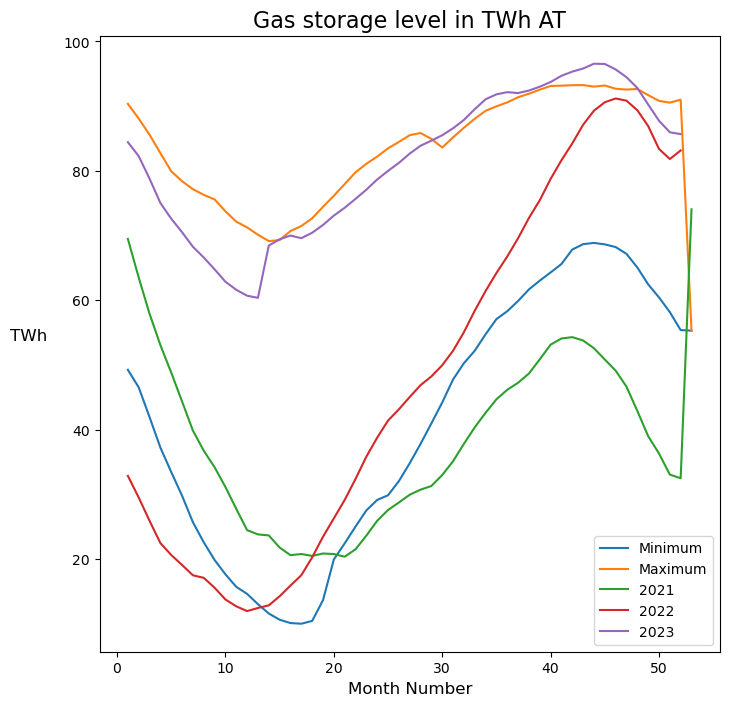

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


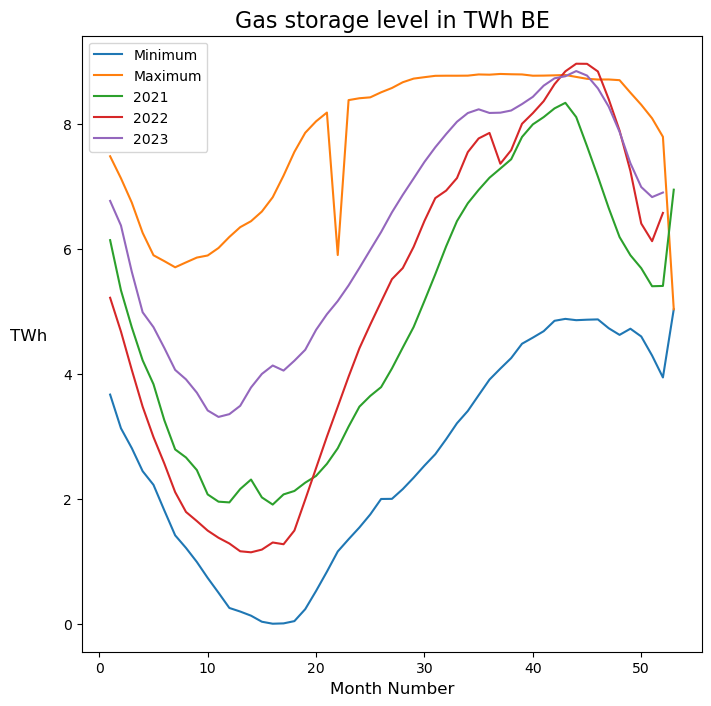

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


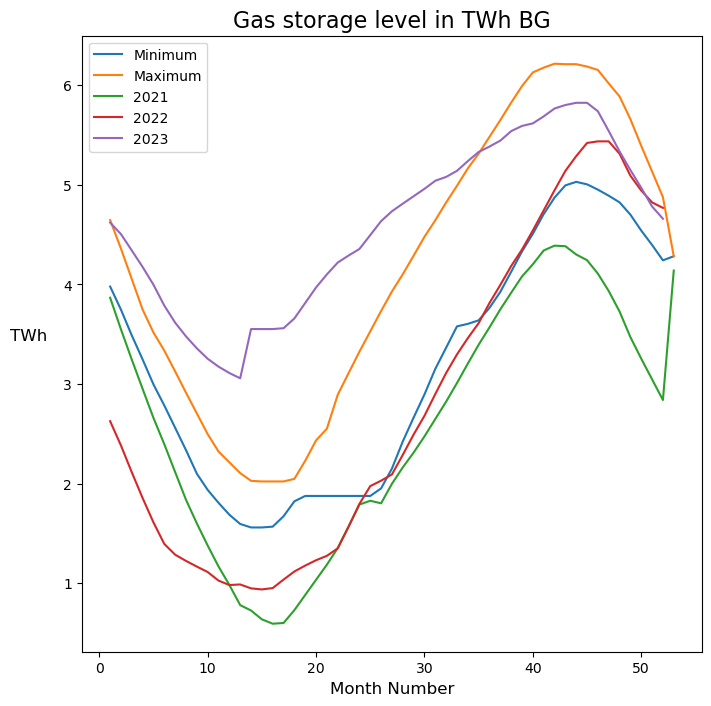

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


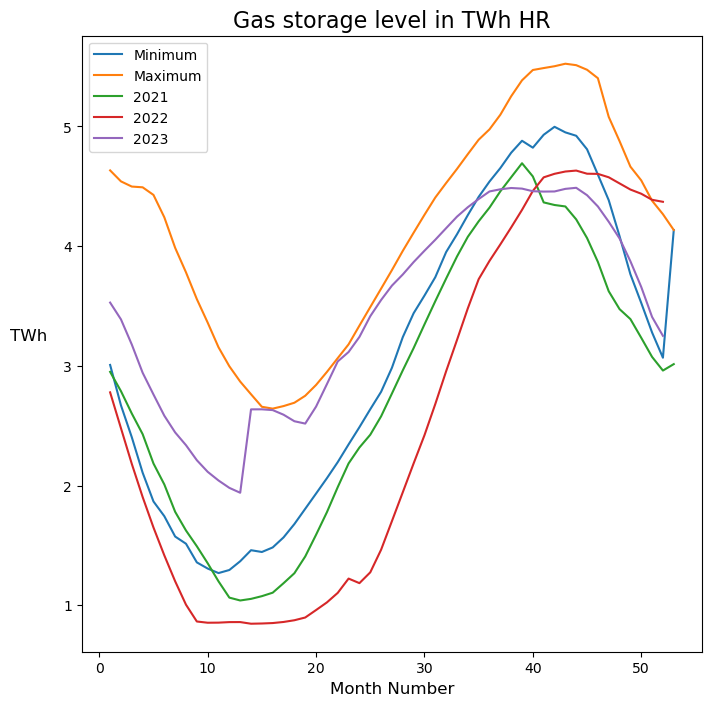

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


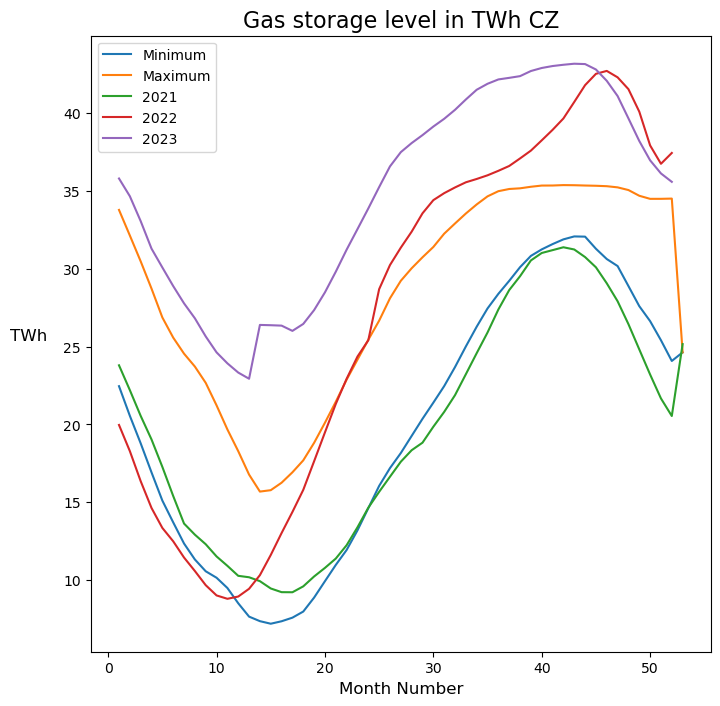

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


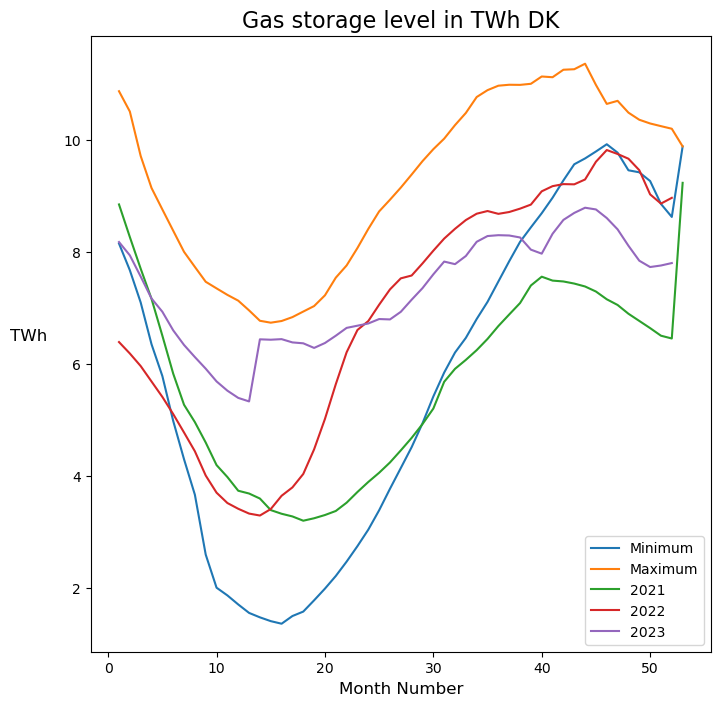

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


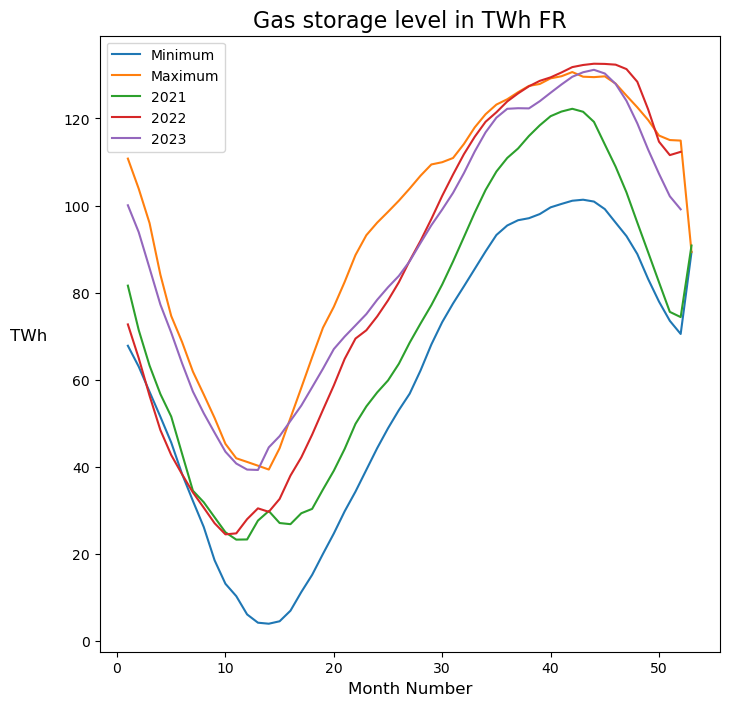

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


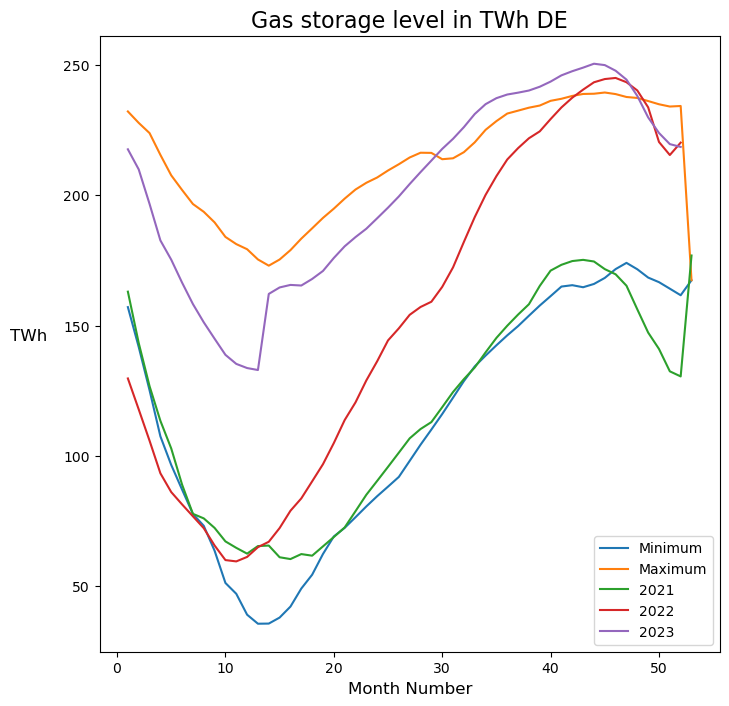

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


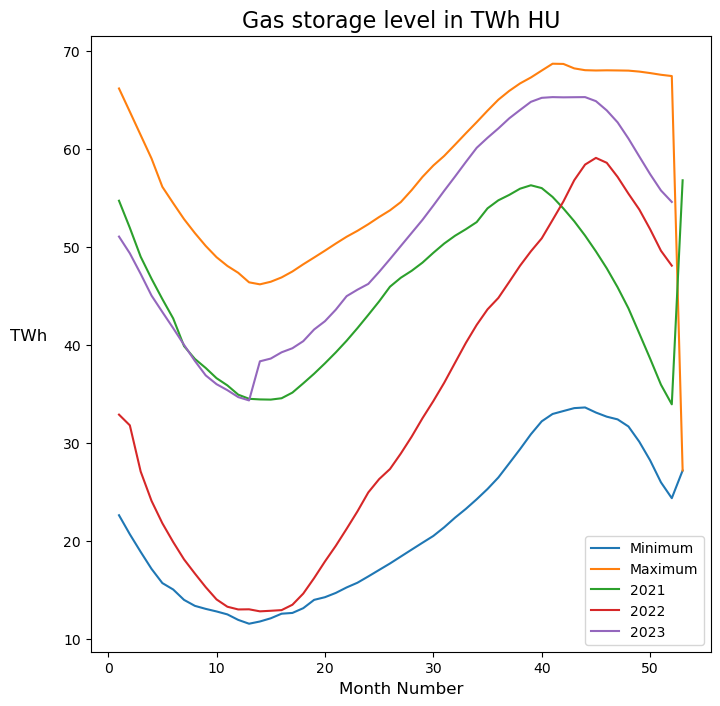

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


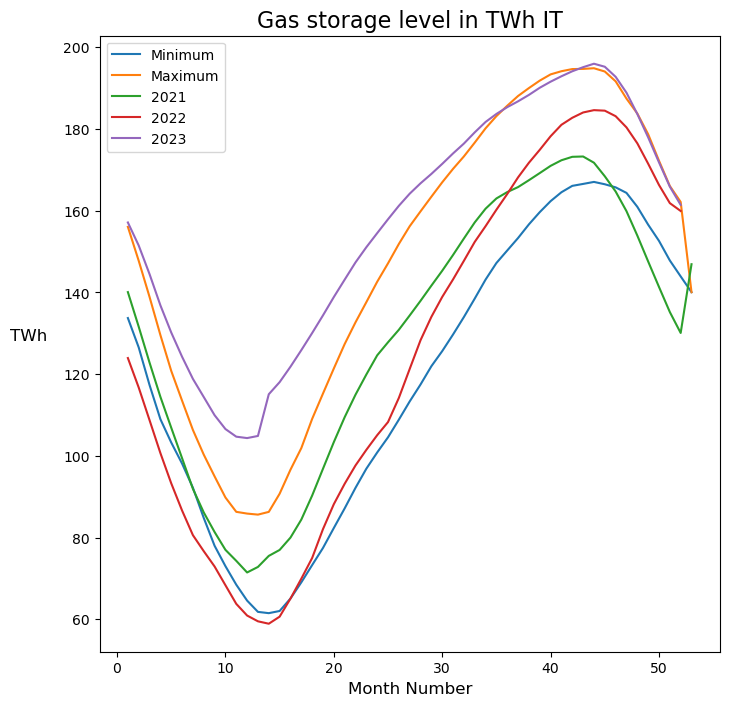

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


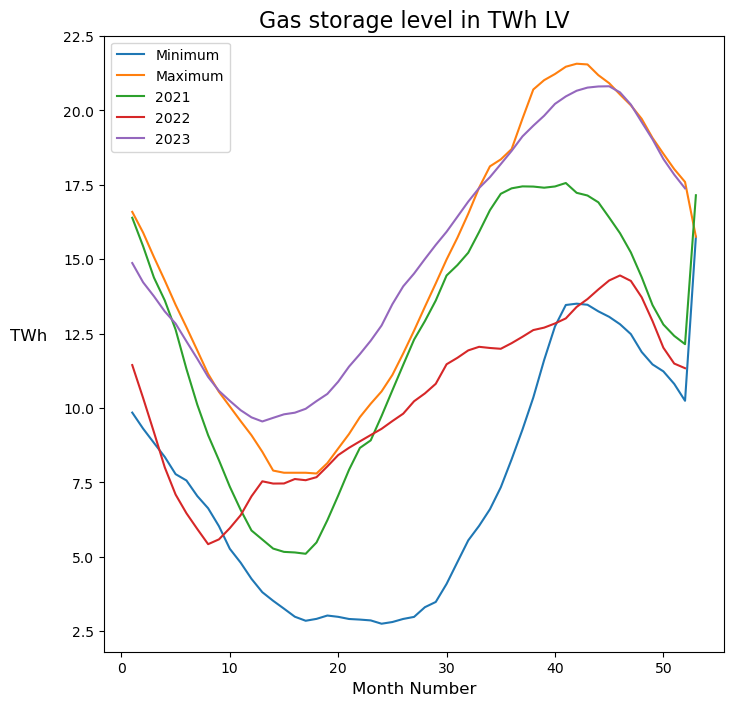

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


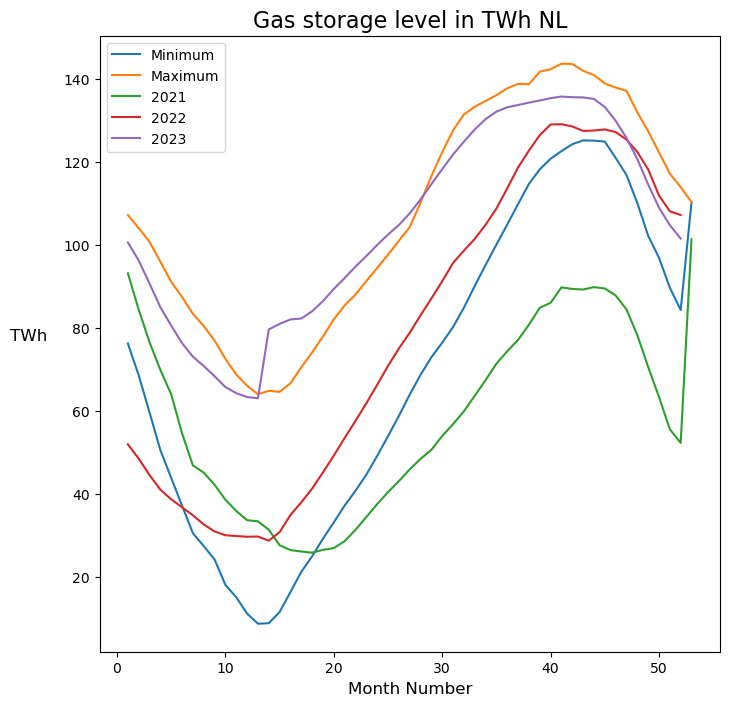

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


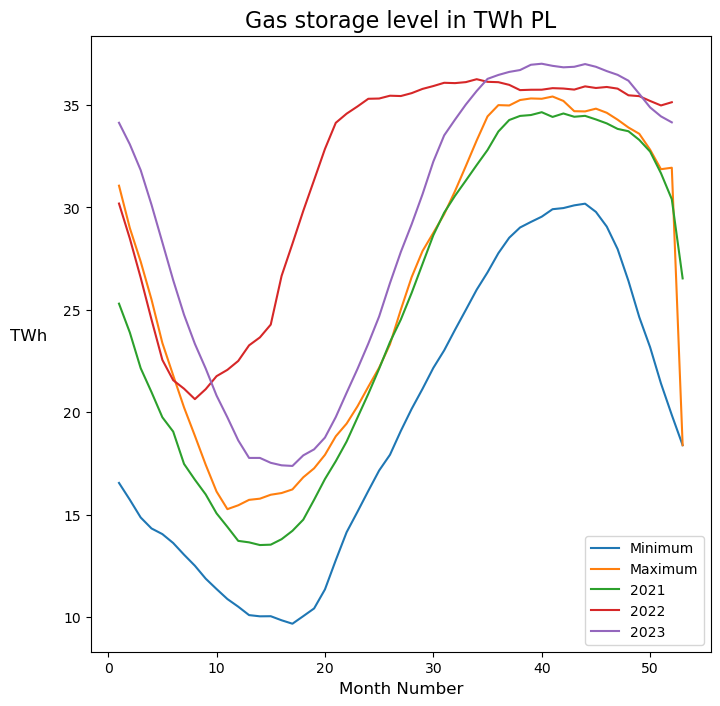

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


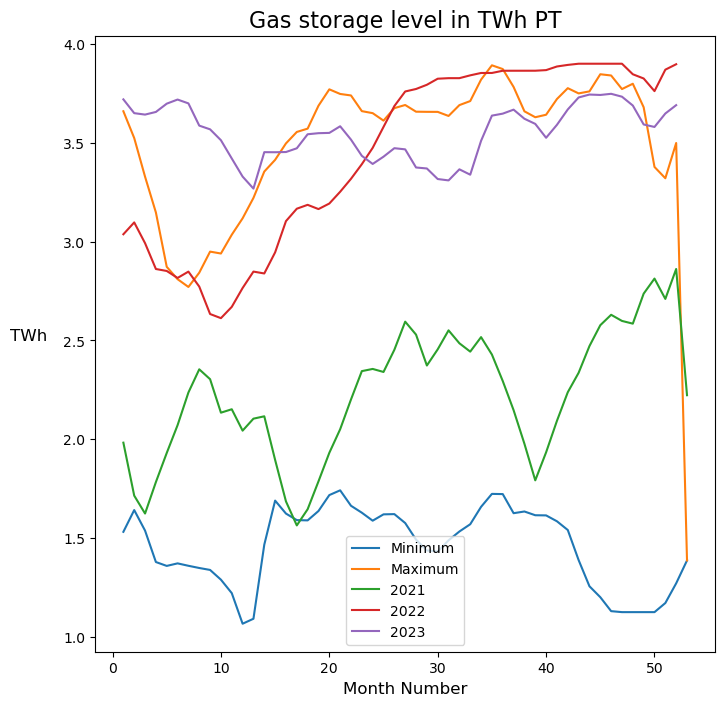

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


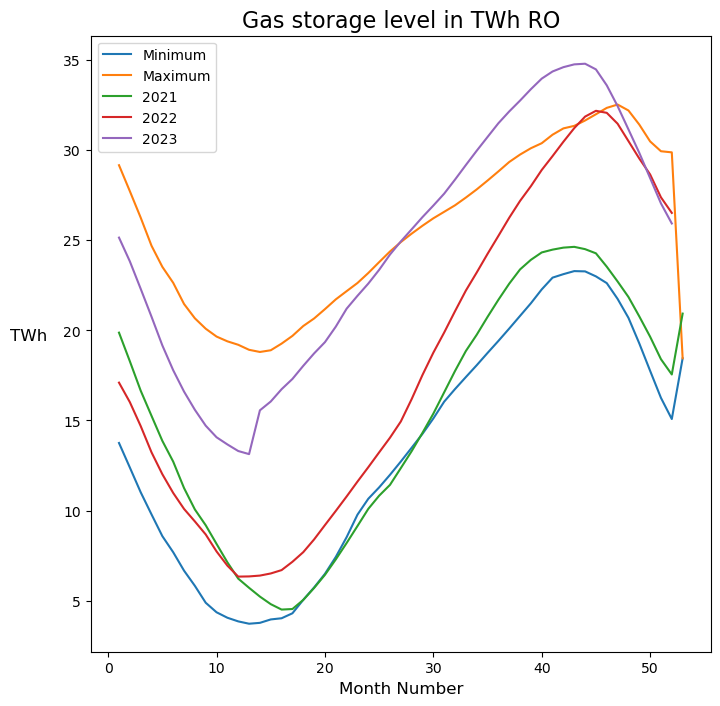

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


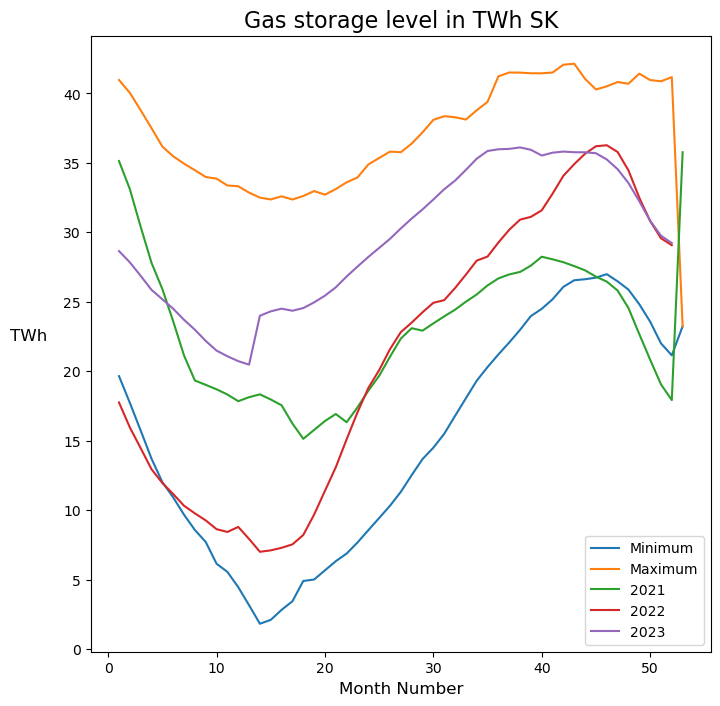

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


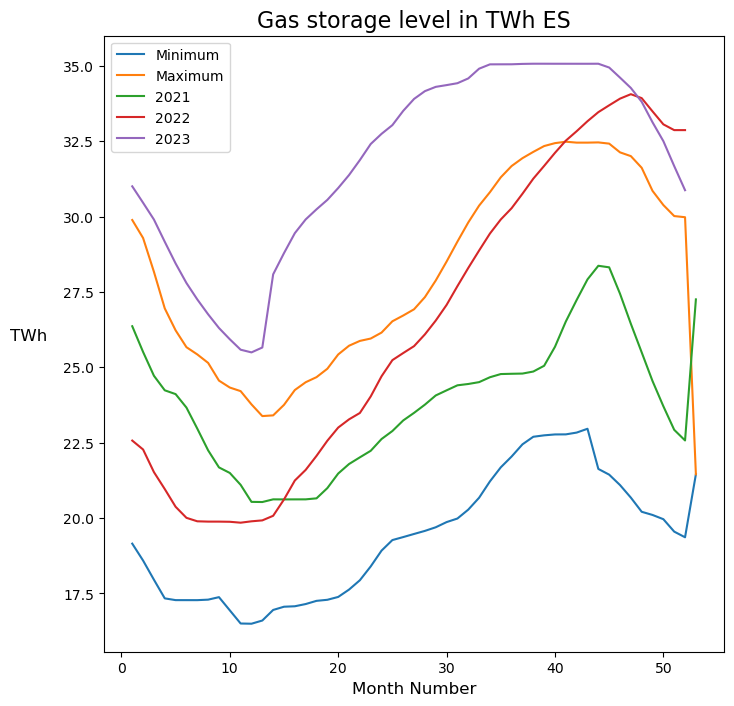

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


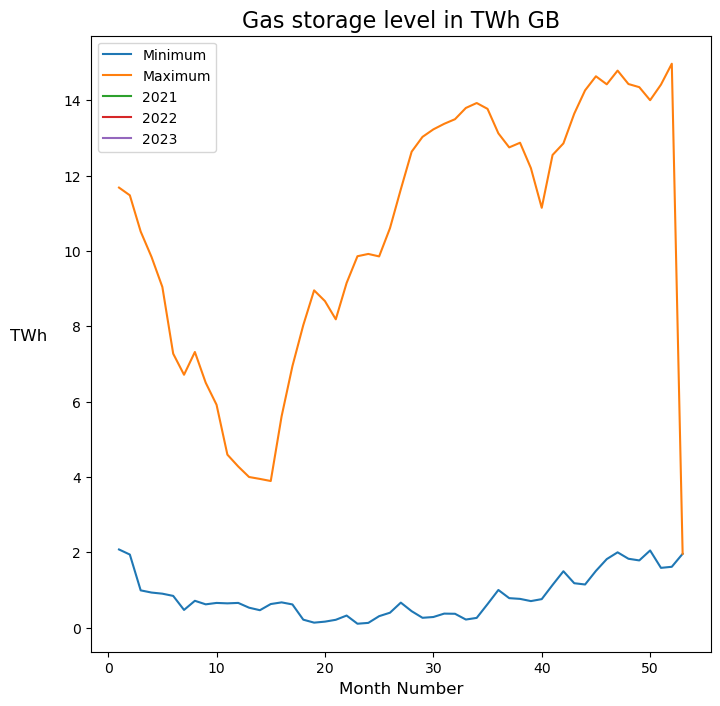

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


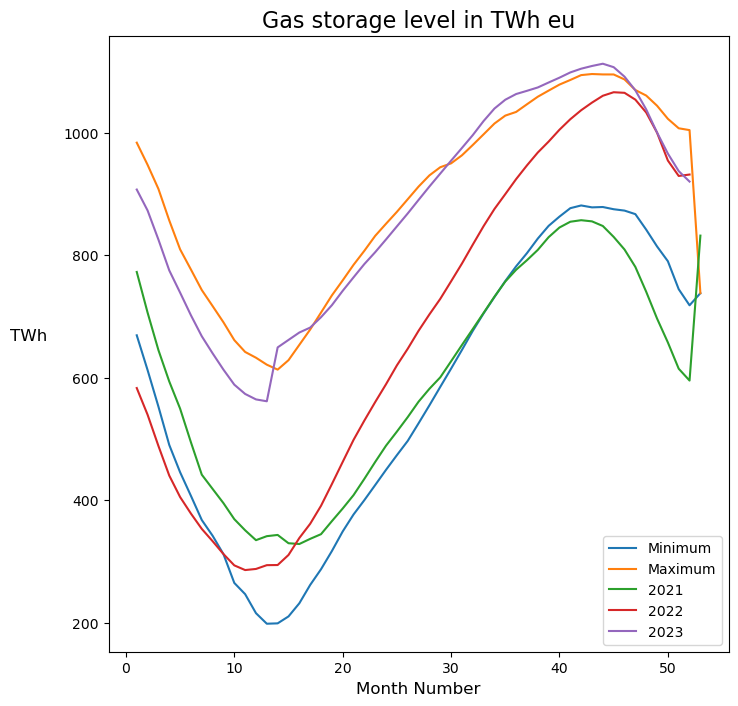

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


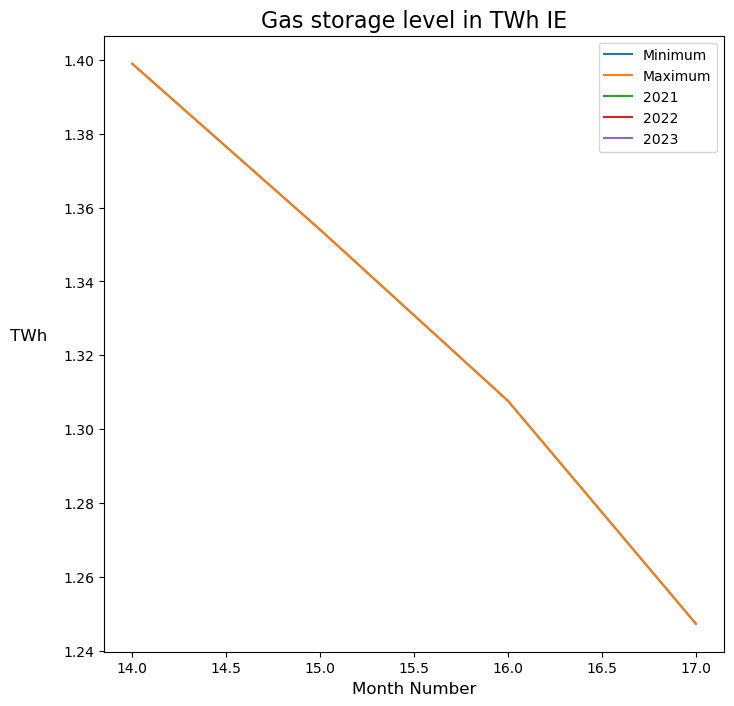

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


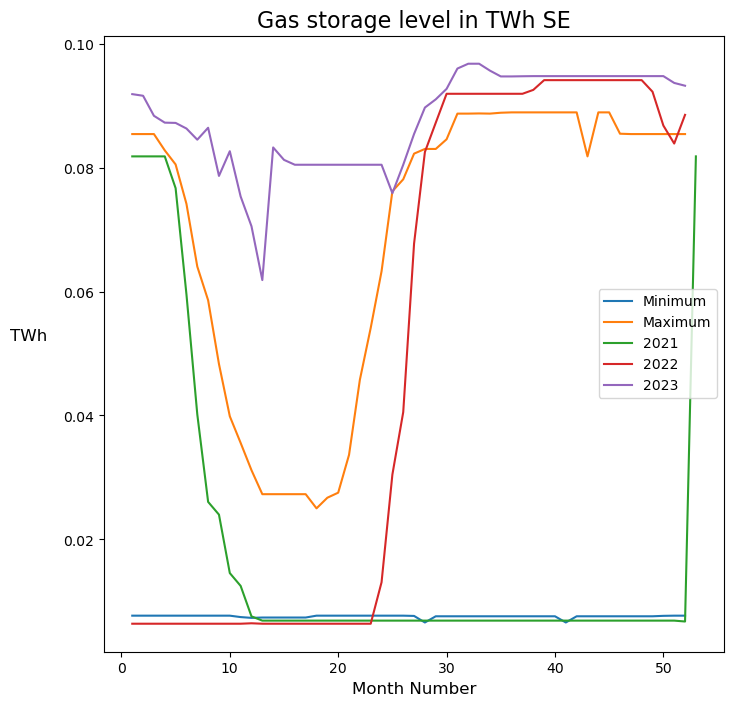

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\2127457911.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


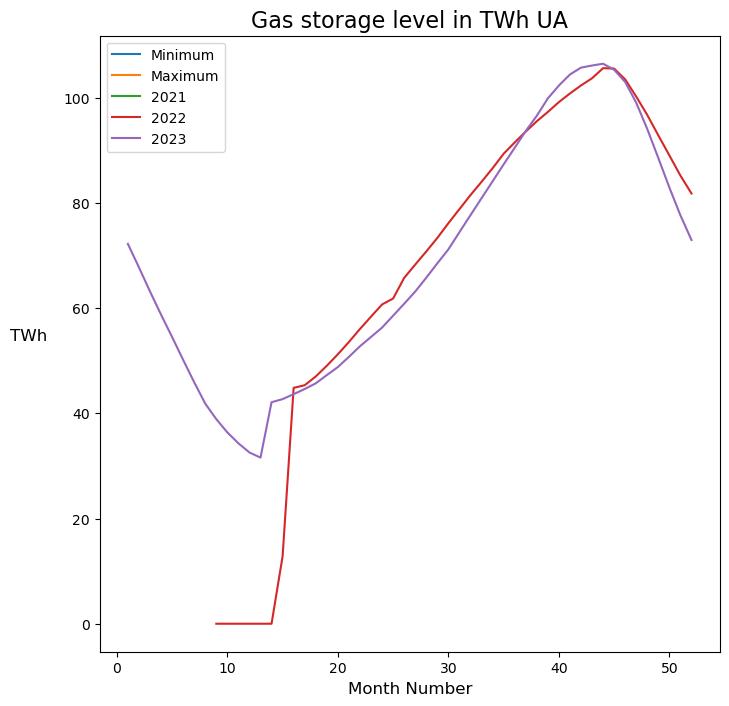

In [237]:
for item in EU:
    country_plot = EUdff[EUdff['country']== '{}'.format(item)].groupby(pd.Grouper(freq='W')).mean(numeric_only=True)[:]
    country_plot['weekly'] = country_plot.index.week
    minvalues = country_plot['2015-01-01':'2020'].groupby(compare).min(numeric_only=True)
    maxvalues = country_plot['2015-01-01':'2020'].groupby(compare).max(numeric_only=True)
    # avgvalues = GazpromPlot['2015-01-05':'2020'].groupby(compare).mean()
    values2021 = country_plot.loc['2021-01-01':'2022-01-02'].groupby(compare).mean(numeric_only=True)
    values2022 = country_plot.loc['2022-01-03':'2023-01-01'].groupby(compare).mean(numeric_only=True)
    values2023 = country_plot.loc['2023-01-02':].groupby(compare).mean(numeric_only=True)
    
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(minvalues,label='Minimum')
    ax.plot(maxvalues,label='Maximum')
    # ax.plot(avgvalues,label='Average')
    ax.plot(values2021,label='2021')
    ax.plot(values2022,label='2022')
    ax.plot(values2023,label='2023')

    plt.title('Gas storage level in TWh {}'.format(item),fontsize='16')
    plt.ylabel('TWh',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Month Number',fontsize=12,rotation=0)
    plt.legend()
    plt.show()
    fig.savefig('Storage by country/countries pics/{}/{}.png'.format(compare,item),dpi=300,bbox_inches="tight")

In [238]:
EUdff.groupby(pd.Grouper(freq='W')).mean()

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_25460\4468400.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  EUdff.groupby(pd.Grouper(freq='W')).mean()


,values
dates,
2015-01-04,78.056170
2015-01-11,75.022378
2015-01-18,71.394854
2015-01-25,66.595539
2015-02-01,61.352308
...,...
2025-03-02,45.713293
2025-03-09,43.132624
2025-03-16,41.448532


### Transform to M3m

In [239]:
converter=0.0103
#compare by week or month
compare = 'weekly'